## Time Series Prediction and Benchmarking with CPU vs GPU-Accelerated scikit-learn Models
**Delegate**: Jiao Chi  
**Mail**: Chijiao2018@163.com

#### Project objectives:
1. Build and benchmark time series prediction models using CPU-based scikit-learn algorithms.
2. Re-implement the same models with same data using accelerated GPU version.
3. Compare the results and draw conclusions on training, inference time and predictive accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
import cudf
import cupy as cp
from cuml.preprocessing import RobustScaler as cuRobustScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.svm import SVC as cuSVC
from cuml.metrics import accuracy_score as cu_acc
import time

## 1. Achieve and clean data
The dataset was firstly imported and processed to generate features and label.

In [2]:
raw = pd.read_csv('https://certificate.tpq.io/eoddata.csv', parse_dates=True, index_col=0)
raw.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,.STOXXE,.V2TX,SPY,EUR=,XAU=,GDX,GLD,BTC=
Date,,,,,,,,,,,,,
2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.3752,1205.29,NaN,NaN,NaN
2014-01-02,19.754623,37.16,25.790,19.8985,176.89,310.44,18.9286,182.920,1.3670,1224.51,22.03,118.00,NaN
2014-01-03,19.320695,36.91,25.780,19.8220,178.15,312.08,18.0018,182.885,1.3587,1236.16,21.83,119.29,NaN
2014-01-06,19.426052,36.13,25.460,19.6815,179.37,311.82,18.1672,182.360,1.3627,1237.59,21.93,119.50,NaN
2014-01-07,19.287034,36.41,25.585,19.9015,178.29,315.30,17.1932,183.480,1.3615,1231.49,21.97,118.82,NaN


In [3]:
df = raw.copy().dropna()
df

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,.STOXXE,.V2TX,SPY,EUR=,XAU=,GDX,GLD,BTC=
Date,,,,,,,,,,,,,
2016-11-14,26.4275,58.12,34.48,35.9535,209.18,324.28,22.1941,216.59,1.0734,1219.86,21.12,116.11,703.82
2016-11-15,26.7775,58.87,34.91,37.1620,211.19,325.75,20.6381,218.28,1.0720,1227.98,22.02,117.12,711.06
2016-11-16,27.4975,59.65,34.84,37.3245,206.26,324.00,21.1147,217.87,1.0685,1224.90,21.84,116.77,739.70
2016-11-17,27.4875,60.64,35.02,37.8200,209.63,325.53,19.9481,218.99,1.0625,1216.01,21.30,116.17,735.50
2016-11-18,27.5150,60.35,34.95,38.0080,210.35,323.96,20.3697,218.50,1.0585,1208.31,21.05,115.15,748.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,247.1000,404.00,24.27,212.7100,626.14,558.04,16.9490,597.21,1.0466,2951.19,40.97,272.21,93978.86
2025-02-25,247.0400,397.90,22.99,212.8000,614.91,557.62,17.7794,594.24,1.0513,2915.12,40.38,268.62,88680.81
2025-02-26,240.3600,399.73,23.52,214.3500,617.77,565.44,16.9863,594.54,1.0483,2916.19,40.86,269.03,84454.71


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2055 entries, 2016-11-14 to 2025-02-28
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AAPL.O   2055 non-null   float64
 1   MSFT.O   2055 non-null   float64
 2   INTC.O   2055 non-null   float64
 3   AMZN.O   2055 non-null   float64
 4   GS.N     2055 non-null   float64
 5   .STOXXE  2055 non-null   float64
 6   .V2TX    2055 non-null   float64
 7   SPY      2055 non-null   float64
 8   EUR=     2055 non-null   float64
 9   XAU=     2055 non-null   float64
 10  GDX      2055 non-null   float64
 11  GLD      2055 non-null   float64
 12  BTC=     2055 non-null   float64
dtypes: float64(13)
memory usage: 224.8 KB


## 2. Create features and label
The dataset was used to generate basic return-based and other features.
Labels were constructed using next-day return direction.
### 2.1 Calculate basic one-day return and log return



In [5]:
data = df.copy()
cols = df.columns
for col in cols:
        data[f'{col}_ret_1'] = data[col].pct_change()
        data[f'{col}_log_ret_1'] = np.log(data[col] / data[col].shift())
data.columns

Index(['AAPL.O', 'MSFT.O', 'INTC.O', 'AMZN.O', 'GS.N', '.STOXXE', '.V2TX',
       'SPY', 'EUR=', 'XAU=', 'GDX', 'GLD', 'BTC=', 'AAPL.O_ret_1',
       'AAPL.O_log_ret_1', 'MSFT.O_ret_1', 'MSFT.O_log_ret_1', 'INTC.O_ret_1',
       'INTC.O_log_ret_1', 'AMZN.O_ret_1', 'AMZN.O_log_ret_1', 'GS.N_ret_1',
       'GS.N_log_ret_1', '.STOXXE_ret_1', '.STOXXE_log_ret_1', '.V2TX_ret_1',
       '.V2TX_log_ret_1', 'SPY_ret_1', 'SPY_log_ret_1', 'EUR=_ret_1',
       'EUR=_log_ret_1', 'XAU=_ret_1', 'XAU=_log_ret_1', 'GDX_ret_1',
       'GDX_log_ret_1', 'GLD_ret_1', 'GLD_log_ret_1', 'BTC=_ret_1',
       'BTC=_log_ret_1'],
      dtype='object')

### 2.2 Add more features to data

In [6]:
# Initiate a empty dictionary to collect features in the column loop.
new_features = {}


# Momentum and volatility features
for col in cols:
    for i in [5, 10, 20]:
        new_features[f'{col}_mom_{i}'] = data[col] / data[col].shift(i) - 1
        new_features[f'{col}_vol_{i}'] = data[f'{col}_log_ret_1'].rolling(i).std()

# Lagged return features
    for i in range(1,6):
        data[f'{col}_ret_lag_{i}'] = data[f'{col}_ret_1'].shift(i)


    new_features[f'{col}_skew_20'] = data[f'{col}_ret_1'].rolling(20).skew()
    new_features[f'{col}_kurt_20'] = data[f'{col}_ret_1'].rolling(20).kurt()
    new_features[f'{col}_min_20'] = data[col].rolling(20).min()
    new_features[f'{col}_max_20'] = data[col].rolling(20).max()

data = pd.concat([data, pd.DataFrame(new_features)], axis=1)


# Market and commpdity features
data['spy_ret'] = data['SPY'].pct_change()                   # Market return
data['spy_mom_10'] = data['SPY'] / data['SPY'].shift(10) - 1   # Market momentum factor
data['vix_change'] = data['.V2TX'].pct_change()              # Volatility change
data['vix_vol'] = data['.V2TX'].rolling(10).std()            # Rolling volatility change
data['gold_ret'] = data['XAU='].pct_change()                 # Commodity price change
data['btc_ret'] = data['BTC='].pct_change()                  # Bitcoin price change
data['gold_spy_ratio'] = data['XAU='] / data['SPY']            # Gold-to-market ratio
data['btc_spy_ratio'] = data['BTC='] / data['SPY']             # Bitcoin-to-market ratio


data.dropna(inplace=True)
print(data.head())
data.columns

             AAPL.O  MSFT.O  INTC.O   AMZN.O    GS.N  .STOXXE    .V2TX  \
Date                                                                     
2016-12-13  28.7975   62.98   36.80  38.7170  238.55   345.23  16.8704   
2016-12-14  28.7975   62.68   36.55  38.4410  239.93   342.84  17.1147   
2016-12-15  28.9550   62.58   36.79  38.0500  243.00   346.50  15.8633   
2016-12-16  28.9925   62.30   36.31  37.8885  238.90   347.57  15.0980   
2016-12-19  29.1600   63.62   36.89  38.3000  239.07   347.53  15.1177   

               SPY    EUR=     XAU=  ...  BTC=_min_20  BTC=_max_20   spy_ret  \
Date                                 ...                                       
2016-12-13  227.76  1.0625  1157.96  ...       711.06       777.11  0.006674   
2016-12-14  225.88  1.0535  1144.12  ...       729.46       777.11 -0.008254   
2016-12-15  226.81  1.0412  1128.34  ...       729.46       777.11  0.004117   
2016-12-16  225.04  1.0447  1133.99  ...       729.46       781.32 -0.007804   
2

Index(['AAPL.O', 'MSFT.O', 'INTC.O', 'AMZN.O', 'GS.N', '.STOXXE', '.V2TX',
       'SPY', 'EUR=', 'XAU=',
       ...
       'BTC=_min_20', 'BTC=_max_20', 'spy_ret', 'spy_mom_10', 'vix_change',
       'vix_vol', 'gold_ret', 'btc_ret', 'gold_spy_ratio', 'btc_spy_ratio'],
      dtype='object', length=242)

### 2.3 Construct labels

In [7]:
for col in cols:
    data['target'] = (df[col].pct_change().shift(-1) > 0).astype(int)
data.head()
feature_data = data.drop(columns=['target'])
target_data = data['target']
feature_data.shape, target_data.shape

((2035, 242), (2035,))

## 3. Data partitioning
The dataset is split chronologically into training and testing sets to preserve temporal order and avoid look-ahead bias.

In [8]:
# Split 70% data for training, 30% data for testing.
train_size = int(len(feature_data) * 0.7)

In [9]:
x_train_cpu, y_train_cpu = feature_data.iloc[:train_size], target_data.iloc[:train_size]
x_test_cpu, y_test_cpu = feature_data.iloc[train_size:], target_data.iloc[train_size:]

x_train_cpu.shape, y_train_cpu.shape, x_test_cpu.shape, y_test_cpu.shape

((1424, 242), (1424,), (611, 242), (611,))

In [10]:
x_train_gpu = cudf.from_pandas(x_train_cpu)
x_test_gpu  = cudf.from_pandas(x_test_cpu)
y_train_gpu = cudf.from_pandas(y_train_cpu)
y_test_gpu  = cudf.from_pandas(y_test_cpu)

## 4. Feature scaling
Eliminating the bias caused by differing feature scales. Accelerating the convergence of gradient descent-based models. Ensuring all features contribute proportionally to the model’s learning process, rather than letting large-scale features overshadow smaller ones.


In [11]:
def robust_scaling(train_df, test_df):
    '''
    Applies Robust Scaling to ensure model convergence while mitigating outlier impact.
    Numerical Method: Uses Interquartile Range (IQR) for scaling instead of Variance.
    '''
    # Initialize RobustScaler
    scaler = RobustScaler()
    scaler.fit(train_df)

    # Transform all sets using training statistics
    trained_cpu = scaler.transform(train_df)
    tested_cpu = scaler.transform(test_df)

    train_scaled_cpu = pd.DataFrame(trained_cpu, columns=train_df.columns, index=train_df.index)
    test_scaled_cpu = scaler.transform(test_df)
    avg_median = train_scaled_cpu.median().mean()
    print(f'Scaling Check: Training Median for CPU is {avg_median:.4f}')
    return train_scaled_cpu, test_scaled_cpu


train_scaled_cpu, test_scaled_cpu = robust_scaling(x_train_cpu, x_test_cpu)

Scaling Check: Training Median for CPU is 0.0000


In [12]:
def robust_scaling_gpu(train_df_gpu, test_df_gpu):
    scaler_gpu = cuRobustScaler()
    scaler_gpu.fit(train_df_gpu)

    train_scaled_gpu = scaler_gpu.transform(train_df_gpu)
    test_scaled_gpu = scaler_gpu.transform(test_df_gpu)
    avg_median = train_scaled_gpu.median().mean()
    print(f'Scaling Check: Training Median for GPU is {avg_median:.4f}')
    return train_scaled_cpu, test_scaled_cpu


train_scaled_gpu, test_scaled_gpu = robust_scaling_gpu(x_train_gpu, x_test_gpu)

Scaling Check: Training Median for GPU is 0.0000


## 5. Class rebalancing
Correcting model bias toward the majority class.

In [13]:
counts = y_train_cpu.value_counts()
c0 = counts.get(0, 0)
c1 = counts.get(1, 0)
counts

,count
target,
1,751
0,673


percentage of class 0:47.26%; percentage of class 1: 52.74%


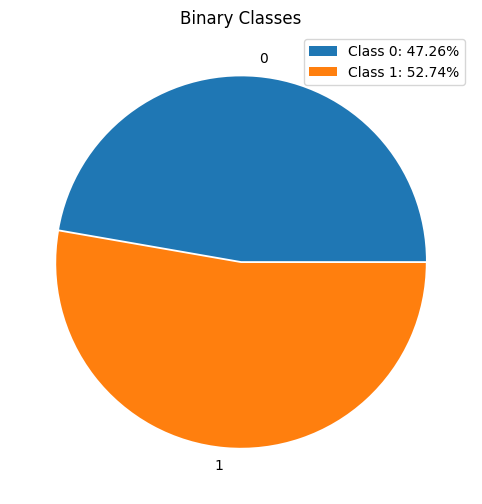

In [14]:
# Claculate the proportion of traing label.
pct_0 = round(c0/(c0+c1), 4)
pct_1 = round(c1/(c0+c1), 4)
print(f'percentage of class 0:{pct_0:.2%}; percentage of class 1: {pct_1:.2%}')

# Visulization the imbalance between classes.
plt.figure(figsize=(10,6))
plt.pie(
        [c0,c1],
        explode=(0.01, 0),
        labels=['0', '1']
        )
plt.title('Binary Classes')
plt.legend(
    labels=[f'Class 0: {pct_0:.2%}', f'Class 1: {pct_1:.2%}'],
)


#### There is no need for class rebalancing given the 47.26% / 52.74% class distribution.

## 6. Build models
### 6.1 Random forest

In [15]:
# Random forest CPU version
rf_cpu = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42
)
# Random forest GPU version
rf_gpu = cuRF(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

### 6.2 XGBoost

In [16]:
# XGBoost CPU version
xgb_cpu = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,

    # use partial features and samples to incease diversification
    colsample_bytree=0.5,  # use 50% features
    subsample=0.8,         # use 80% samples

    # use regularization to prevent from overfitting
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=1,          # L2 regularization

    tree_method='hist',
    device='cpu',
    random_state=42,
    eval_metric='logloss'
)

# XGBoost GPU version
xgb_gpu = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=0.5,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    tree_method='hist',
    device='cuda',    # Start GPU
    random_state=42,
    eval_metric='logloss'
)



### 6.3 SVM

In [17]:
# SVM CPU version
svm_cpu = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=False,
    class_weight=None
)

# SVM GPU version
svm_gpu = cuSVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)


### 6.4 Logistic regression

In [18]:
# Logistic regression CPU version
logit_cpu = LogisticRegression(
    penalty='l2',             # L2 regularization
    C=1,
    class_weight=None,
    random_state=42,
    max_iter=1000
)

# Logistic regression GPU version
logit_gpu = cuLogisticRegression(
    penalty='l2',
    C=1,
    max_iter=1000
)



## 7. cuML Integration & GPU Acceleration

In [19]:
model = ['rf_cpu', 'rf_gpu', 'xgb_cpu', 'xgb_gpu', 'svm_cpu', 'svm_gpu', 'logit_cpu', 'logit_gpu']
# Compare time and accuracies for a single model.
def compare(model,
            x_train_cpu, train_scaled_cpu, y_train_cpu,
            x_train_gpu, train_scaled_gpu, y_train_gpu,
            x_test_cpu, test_scaled_cpu, y_test_cpu,
            x_test_gpu, test_scaled_gpu, y_test_gpu,
            name='Model'):

    # Prepare data
    if 'gpu' in name.lower():
        # use gpu-relative data
        is_gpu = True
        if 'logit' in name or 'svm' in name:
            train_data = train_scaled_gpu
            test_data = test_scaled_gpu
        else:
            train_data = x_train_gpu
            test_data = x_test_gpu
        y_train_data = y_train_gpu
        y_test_data = y_test_gpu

    else:
        # use cpu-relative data
        is_gpu = False
        if 'logit' in name or 'svm' in name:
            train_data = train_scaled_cpu
            test_data = test_scaled_cpu
        else:
            train_data = x_train_cpu
            test_data = x_test_cpu

        y_train_data = y_train_cpu
        y_test_data = y_test_cpu

    # Training process
    start = time.perf_counter()
    model.fit(train_data, y_train_data)
    train_time = time.perf_counter() - start

    # Prediction
    start = time.perf_counter()
    y_pred = model.predict(test_data)
    pred_time = time.perf_counter() - start

    # Evaluation
    # GPU prediction results are cuDF, which should be tranformed to pandas
    if hasattr(y_pred, 'to_pandas'):
        y_pred_pd = y_pred.to_pandas()
    else:
        y_pred_pd = y_pred

    if hasattr(y_test_data, 'to_pandas'):
        y_test_pd = y_test_data.to_pandas()
    else:
        y_test_pd = y_test_data

    if is_gpu:
        acc = float(cu_acc(y_test_data, y_pred))
    else:
        acc = accuracy_score(y_test_data, y_pred)

    # Conclusion
    print(f'{name} | Train: {train_time:.4f}s | Predict: {pred_time:.4f}s | Accuracy: {acc:.4f}')
    return {
        'name': name,
        'train_time': train_time,
        'pred_time': pred_time,
        'accuracy': acc
    }


In [20]:
# Build the implementation funtion of all models.
model_dict = {
    'rf_cpu': rf_cpu,
    'rf_gpu': rf_gpu,
    'xgb_cpu': xgb_cpu,
    'xgb_gpu': xgb_gpu,
    'svm_cpu': svm_cpu,
    'svm_gpu': svm_gpu,
    'logit_cpu': logit_cpu,
    'logit_gpu': logit_gpu
}

def run_all_models(model_dict,
                   x_train_cpu, train_scaled_cpu, y_train_cpu,
                   x_train_gpu, train_scaled_gpu, y_train_gpu,
                   x_test_cpu, test_scaled_cpu, y_test_cpu,
                   x_test_gpu, test_scaled_gpu, y_test_gpu):
    '''
    Function of implementing all models and saving results.
    '''
    results = []
    cpu_results = {}   # only contains cpu-related results.

    for name, model in model_dict.items():
        res = compare(model,
                      x_train_cpu, train_scaled_cpu, y_train_cpu,
                      x_train_gpu, train_scaled_gpu, y_train_gpu,
                      x_test_cpu, test_scaled_cpu, y_test_cpu,
                      x_test_gpu, test_scaled_gpu, y_test_gpu,
                      name=name)
        results.append(res)

        if name.endswith('cpu'):
            cpu_results[name] = res

    results_df = pd.DataFrame(results)   # Only cpu results

    # Calculate speed-up
    results_df['train_speedup'] = 1   # initialize with 1
    results_df['pred_speedup']  = 1

    gpu_mask = results_df['name'].str.endswith('gpu')   # Select gpu models


    results_df.loc[gpu_mask, 'train_speedup'] = results_df.loc[gpu_mask, 'name'].apply(
        lambda n: cpu_results[n.replace('gpu','cpu')]['train_time'] /
        results_df.loc[results_df['name']==n, 'train_time'].values[0]
    )
    results_df.loc[gpu_mask, 'pred_speedup'] = results_df.loc[gpu_mask, 'name'].apply(
        lambda n: cpu_results[n.replace('gpu','cpu')]['pred_time'] /
        results_df.loc[results_df['name']==n, 'pred_time'].values[0]
    )
    return results_df

In [21]:
%%time
# Run all models to collect results of time and accuracies.
result = run_all_models(
    model_dict,
    x_train_cpu, train_scaled_cpu, y_train_cpu,
    x_train_gpu, train_scaled_gpu, y_train_gpu,
    x_test_cpu, test_scaled_cpu, y_test_cpu,
    x_test_gpu, test_scaled_gpu, y_test_gpu
    )
display(result)


rf_cpu | Train: 16.8687s | Predict: 0.0580s | Accuracy: 0.5041
rf_gpu | Train: 1.2444s | Predict: 0.0547s | Accuracy: 0.5041
xgb_cpu | Train: 3.3687s | Predict: 0.0120s | Accuracy: 0.5106
xgb_gpu | Train: 1.1109s | Predict: 0.0520s | Accuracy: 0.5172


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


svm_cpu | Train: 0.2475s | Predict: 0.1638s | Accuracy: 0.4975
svm_gpu | Train: 0.1294s | Predict: 0.0185s | Accuracy: 0.4975
logit_cpu | Train: 0.1130s | Predict: 0.0007s | Accuracy: 0.5041
logit_gpu | Train: 0.1039s | Predict: 0.0039s | Accuracy: 0.5041


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/tmp/ipython-input-45274/4241736490.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[13.55516036  3.03244505  1.91202988  1.08775249]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results_df.loc[gpu_mask, 'train_speedup'] = results_df.loc[gpu_mask, 'name'].apply(
/tmp/ipython-input-45274/4241736490.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.0609597  0.23029789 8.83955968 0.18765442]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results_df.loc[gpu_mask, 'pred_speedup'] = results_df.loc[gpu_mask, 'name'].apply(


,name,train_time,pred_time,accuracy,train_speedup,pred_speedup
0,rf_cpu,16.868711,0.058009,0.504092,1.000000,1.000000
1,rf_gpu,1.244449,0.054676,0.504092,13.555160,1.060960
2,xgb_cpu,3.368658,0.011966,0.510638,1.000000,1.000000
3,xgb_gpu,1.110872,0.051959,0.517185,3.032445,0.230298
4,svm_cpu,0.247469,0.163834,0.497545,1.000000,1.000000
5,svm_gpu,0.129427,0.018534,0.497545,1.912030,8.839560
6,logit_cpu,0.113019,0.000741,0.504092,1.000000,1.000000
7,logit_gpu,0.103901,0.003950,0.504092,1.087752,0.187654


CPU times: user 21.7 s, sys: 893 ms, total: 22.6 s
Wall time: 23.6 s


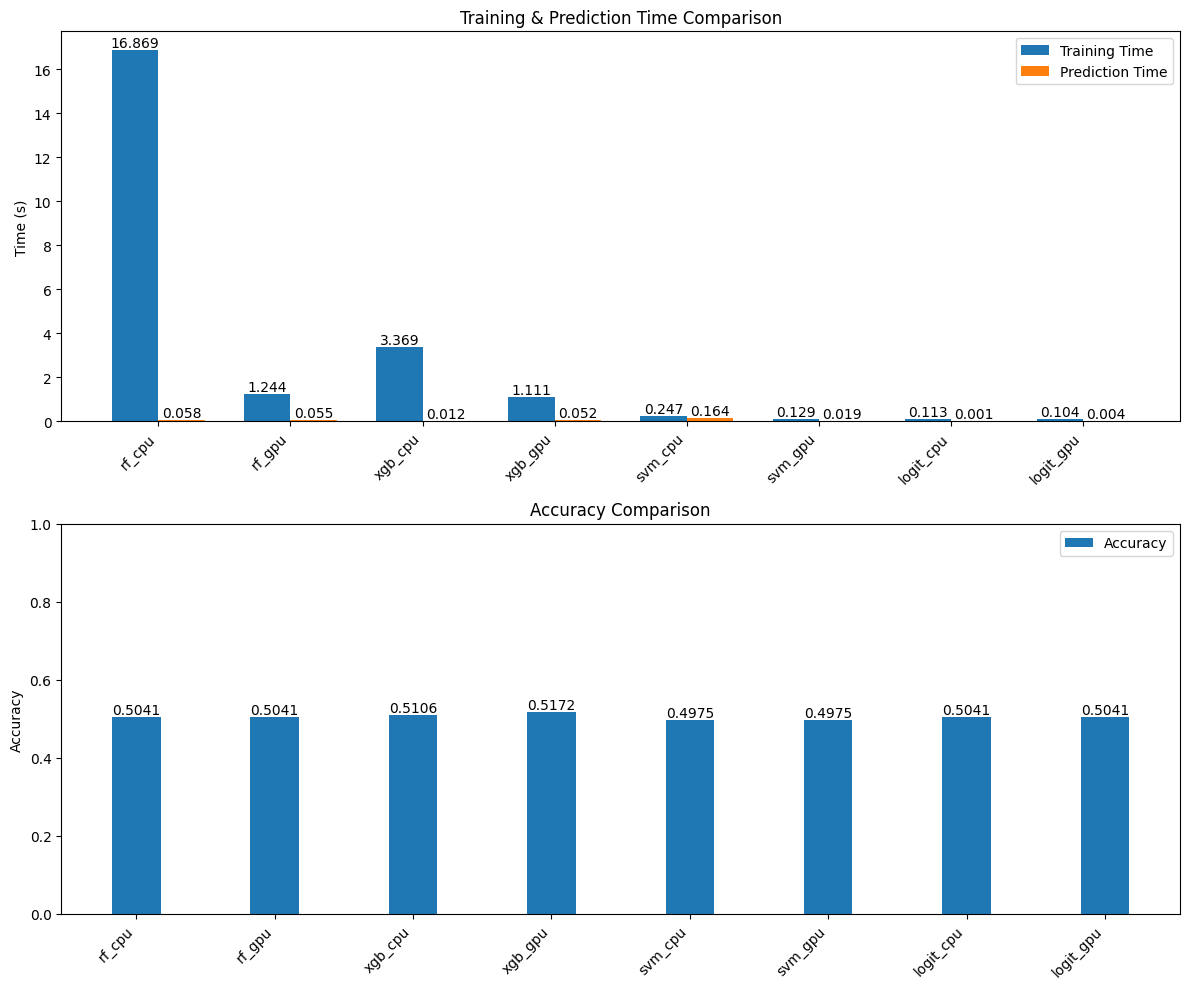

In [22]:
import matplotlib.pyplot as plt
import numpy as np

model_names = result['name']
train_times  = result['train_time']
pred_times   = result['pred_time']
accuracies   = result['accuracy']

width = 0.35
x = np.arange(len(model_names))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Subplot 1：Compare time with CPU and GPU
bar1 = ax1.bar(x - width/2, train_times, width, label='Training Time')
bar2 = ax1.bar(x + width/2, pred_times, width, label='Prediction Time')

ax1.set_title('Training & Prediction Time Comparison')
ax1.set_ylabel('Time (s)')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.bar_label(bar1, fmt='%.3f')
ax1.bar_label(bar2, fmt='%.3f')

# Subplot 2: Display accuracy across models
bar3 = ax2.bar(x, accuracies, width, label='Accuracy')

ax2.set_title('Accuracy Comparison')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.bar_label(bar3, fmt='%.4f')

plt.tight_layout()
plt.show()

## Key findings
**Training Time**: GPU acceleration delivers dramatic speed improvements for tree-based models: Random Forest (13x time with cpu compare to gpu) and XGBoost (3x). SVM shows modest GPU speed-up (1.9x), while Logistic Regression has a slight GPU speed-up (1.09x).

**Prediction Time**: GPU prediction is much faster for SVM (8x time with cpu compare to gpu) and comparable to Random Forest(1.06x).
Notably, XGBoost and Logistic regression both presents much slower with gpu compare to cpu.

**Accuracy**: All GPU models maintain identical or near-identical accuracy to their CPU counterparts:
Random Forest/Logistic Regression: 0.5041 (CPU/GPU parity)
SVM: 0.4975 (CPU/GPU parity)
XGBoost: GPU accuracy (0.5172) marginally outperforms CPU (0.5106)
No accuracy degradation is observed with GPU acceleration.

## Conclusion
1. GPU add value only for RF/XGBoost training in this project: 13x/3x speedups justify GPU use for large-scale retraining, but not for small datasets.

2. CPU is preferable for Logistic Regression/SVM: Negligible GPU speed gains + lower complexity/cost make CPUs the pragmatic choice.

3. GPU is not always the first choice when using models. GPU adoption should be driven by data size, cost-benefit alignment, and overhead aspects.